# Project 04: Shipping Price Optimisation

> Which shipping option should you show — and at what price — to maximise margin without hurting conversion?

---

## Problem

At checkout, a flat shipping rate is the norm: everyone sees the same menu at the same prices.
This is optimal for no one.

- **Sure-things** convert even at a $12.99 express fee. Charging them $4.99 is a free margin giveaway.
- **Persuadables** only convert with free or low-cost shipping. Charging them $4.99 loses the order entirely.
- **Lost causes** won't convert at any price. Price barely matters.
- **Sleeping dogs** convert slightly *better* at higher prices — a perceived quality or urgency signal.

A segment-aware pricing policy extracts more margin from sure-things while subsidising persuadables — and the order still profits after the shipping cost is covered.

## Approach

**Causal identification via A/B test design.** Each session in the training data is randomly assigned one shipping price from a fixed menu. Because assignment is random, the price coefficient in the model estimates a genuine causal effect — not a spurious correlation between price and user quality.

**Optimisation objective.** For each session with features X and candidate price p:

$$E[\text{margin} \mid X, p] = P(\text{convert} \mid X, p) \times (\text{cart\_value} \times 0.35 + p - 4.50)$$

Select the option that maximises this. No separate conversion constraint is needed — the objective penalises prices that lose conversions because unconverted sessions contribute zero margin.

**Model.** Calibrated LightGBM classifier on session features + shipping price.
Isotonic calibration ensures predicted probabilities are well-calibrated for use in the margin formula.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

sys.path.insert(0, str(Path.cwd() / 'src'))
from shipping.elasticity import ConversionElasticityModel
from shipping.optimizer import FLAT_RATE_OPTION, SHIPPING_OPTIONS, ShippingPriceOptimizer
from shipping.synthetic import (
    PRODUCT_MARGIN_RATE,
    SEGMENT_NAMES,
    SHIPPING_COST_TO_MERCHANT,
    generate_shipping_dataset,
)

sns.set_theme(style='whitegrid', palette='muted')
RESULTS = Path.cwd() / 'results'

df    = pd.read_parquet(RESULTS / 'sessions.parquet')
model = ConversionElasticityModel.load(RESULTS / 'elasticity_model.pkl')
_, test_df = train_test_split(df, test_size=0.20, random_state=42)

print(f'Sessions: {len(df):,}  (train={len(df)-len(test_df):,} / test={len(test_df):,})')
print(f'Elasticity model PR-AUC: {model.pr_auc_:.4f}  (random = {df["converted"].mean():.4f})')

Sessions: 60,000  (train=48,000 / test=12,000)
Elasticity model PR-AUC: 0.7257  (random = 0.4295)


---
## 1. The core pattern: price sensitivity varies radically by segment

The model's job is to learn this from session features. Before evaluating the model, it's worth showing that the pattern exists and is recoverable from the data.

/var/folders/8s/pl048ybd07zgjyl70_360wc00000gq/T/ipykernel_13701/4126791345.py:41: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8s/pl048ybd07zgjyl70_360wc00000gq/T/ipykernel_13701/4126791345.py:42: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.savefig(RESULTS / 'report_elasticity.png', dpi=130, bbox_inches='tight')
/Users/u0933981/Desktop/Work/commerce-ml-lab/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


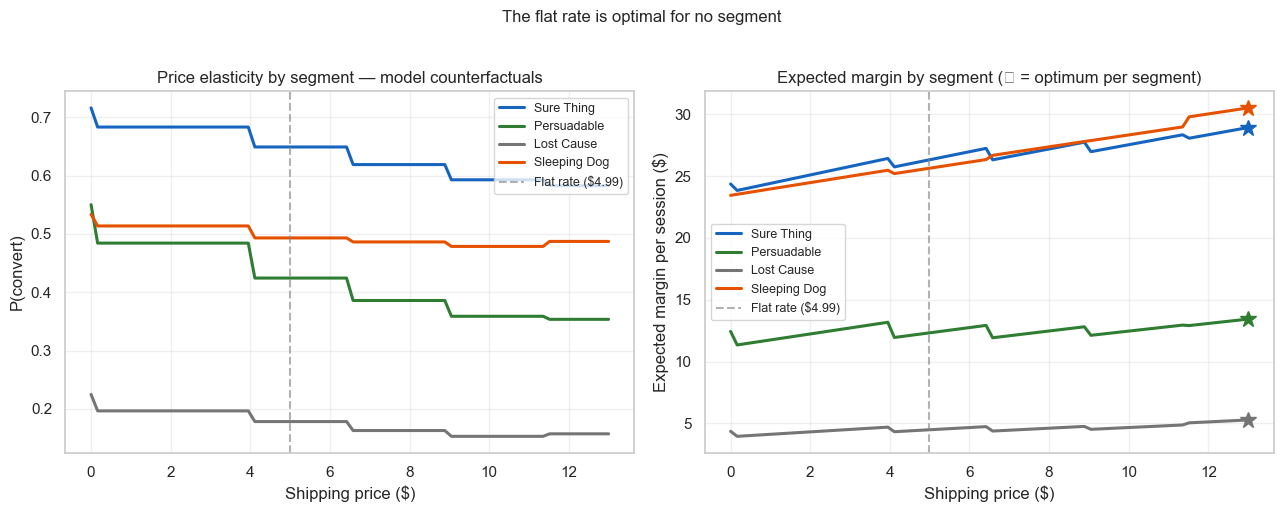

In [2]:
seg_colors = {
    'sure_thing': '#1565C0', 'persuadable': '#2E7D32',
    'lost_cause': '#757575', 'sleeping_dog': '#E65100',
}
prices_fine = np.linspace(0, 13, 80)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for seg in SEGMENT_NAMES:
    seg_df = test_df[test_df['segment'] == seg].head(400)
    label  = seg.replace('_', ' ').title()
    color  = seg_colors[seg]

    p_curve  = [model.predict_at_price(seg_df, p).mean() for p in prices_fine]
    em_curve = [
        (model.predict_at_price(seg_df, p) *
         (seg_df['cart_value'] * PRODUCT_MARGIN_RATE + p - SHIPPING_COST_TO_MERCHANT)).mean()
        for p in prices_fine
    ]

    axes[0].plot(prices_fine, p_curve,  color=color, linewidth=2.2, label=label)
    axes[1].plot(prices_fine, em_curve, color=color, linewidth=2.2, label=label)

    # Star at optimum
    best_p_  = prices_fine[np.argmax(em_curve)]
    best_em_ = max(em_curve)
    axes[1].plot(best_p_, best_em_, '*', color=color, markersize=12)

for ax in axes:
    ax.axvline(FLAT_RATE_OPTION.price, color='grey', linestyle='--', alpha=0.6,
               label=f'Flat rate (${FLAT_RATE_OPTION.price:.2f})')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[0].set(xlabel='Shipping price ($)', ylabel='P(convert)',
            title='Price elasticity by segment — model counterfactuals')
axes[1].set(xlabel='Shipping price ($)', ylabel='Expected margin per session ($)',
            title='Expected margin by segment (⭐ = optimum per segment)')

plt.suptitle('The flat rate is optimal for no segment', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS / 'report_elasticity.png', dpi=130, bbox_inches='tight')
plt.show()

**Reading the chart:**
- Sure-things (blue): flat conversion rate across all prices. Optimal price = Express ($12.99). Charging $4.99 leaves $8 of shipping revenue uncollected per session.
- Persuadables (green): steep price sensitivity. Free shipping roughly doubles their conversion rate. The order still profits because product margin covers the subsidised shipping.
- Sleeping dogs (orange): counterintuitively, a higher price slightly improves conversion — possibly a perceived quality/urgency signal.
- Lost causes (grey): near-zero conversion at every price. Express maximises expected margin (tiny, but positive).

---
## 2. Policy comparison

In [3]:
optimizer  = ShippingPriceOptimizer(model)
policy_df  = optimizer.compare_policies(test_df)

flat_row = policy_df[policy_df['policy'].str.startswith('Flat')].iloc[0]
opt_row  = policy_df[policy_df['policy'].str.startswith('Opt')].iloc[0]

margin_lift = (opt_row.mean_expected_margin - flat_row.mean_expected_margin) / abs(flat_row.mean_expected_margin)
conv_delta  = (opt_row.mean_p_convert - flat_row.mean_p_convert) * 100

print(policy_df.to_string(index=False))
print(f'\nOptimised vs flat rate:')
print(f'  Margin:     +{margin_lift:.1%}')
print(f'  Conversion: {conv_delta:+.1f} pp')
print()
print('Note: optimised policy improves BOTH margin AND conversion.')
print('This happens because persuadables convert more with free shipping,')
print('more than offsetting the small effect on other segments.')

                         policy  mean_expected_margin  mean_p_convert  margin_per_converted
              Flat rate ($4.99)               16.5550          0.4310               38.4099
           Always free shipping               15.6409          0.5049               30.9805
        Always Express ($12.99)               18.7477          0.3870               48.4414
Optimised (max expected margin)               19.2708          0.4443               43.3761

Optimised vs flat rate:
  Margin:     +16.4%
  Conversion: +1.3 pp

Note: optimised policy improves BOTH margin AND conversion.
This happens because persuadables convert more with free shipping,
more than offsetting the small effect on other segments.


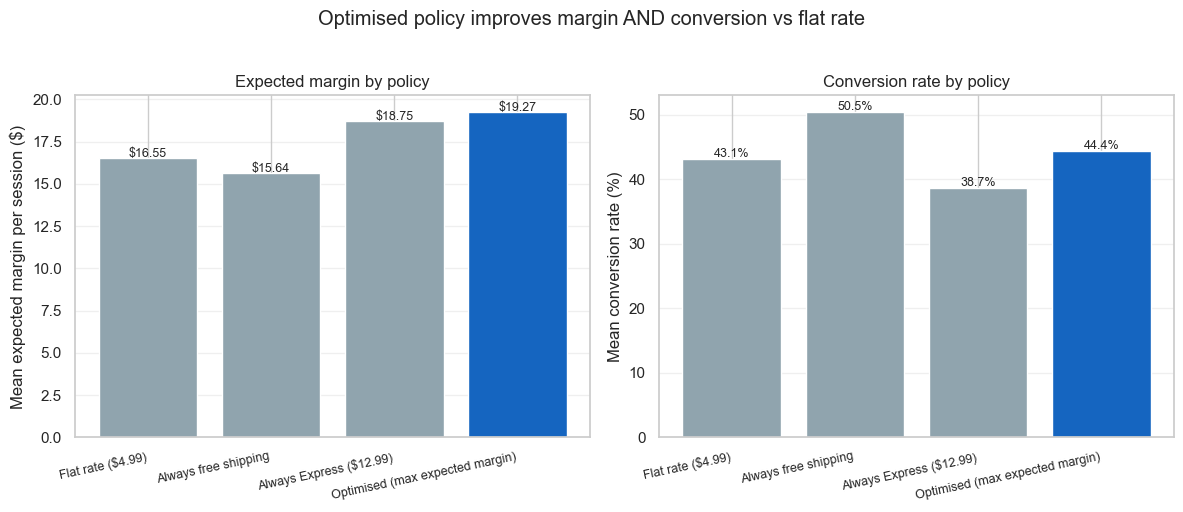

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = policy_df['policy'].tolist()
x      = np.arange(len(labels))
colors = ['#90A4AE'] * (len(labels) - 1) + ['#1565C0']

axes[0].bar(x, policy_df['mean_expected_margin'], color=colors)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=12, ha='right', fontsize=9)
axes[0].set(ylabel='Mean expected margin per session ($)',
            title='Expected margin by policy')
for i, v in enumerate(policy_df['mean_expected_margin']):
    axes[0].text(i, v + 0.05, f'${v:.2f}', ha='center', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, policy_df['mean_p_convert'] * 100, color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=12, ha='right', fontsize=9)
axes[1].set(ylabel='Mean conversion rate (%)', title='Conversion rate by policy')
for i, v in enumerate(policy_df['mean_p_convert']):
    axes[1].text(i, v * 100 + 0.3, f'{v:.1%}', ha='center', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Optimised policy improves margin AND conversion vs flat rate', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS / 'report_policy_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 3. Which options get recommended?

The optimiser assigns different tiers to different segments — this should map directly to the business intuition.

In [5]:
seg_price = optimizer.segment_price_distribution(test_df)
print('Recommended shipping tier by segment (optimised policy):')
print(seg_price.round(3).to_string())

Recommended shipping tier by segment (optimised policy):
recommended_label  Expedited  Express  Free Shipping  Standard
segment                                                       
lost_cause             0.041    0.748          0.180     0.031
persuadable            0.043    0.557          0.364     0.036
sleeping_dog           0.021    0.805          0.144     0.030
sure_thing             0.061    0.775          0.127     0.037


---
## 4. Connection to Project 03 — Checkout Uplift

The segment decomposition from Project 03's CATE analysis maps directly onto this pricing strategy:

| Segment | CATE (P03) | Optimal shipping | Logic |
|---------|-----------|-----------------|-------|
| Persuadable | +12.3% | Free | Free shipping **is** the treatment that converts them |
| Sure-thing | +1.0% | Express | Converts regardless — recover shipping cost |
| Lost cause | ~0% | Express | Won't convert either way |
| Sleeping dog | −2.0% | Express | Discount would *reduce* conversion |

This project is the natural downstream layer of the uplift model: CATE estimation identifies who responds to interventions, and shipping pricing is one such intervention.
The same architecture — segment prediction → decision policy — applies across demand forecasting, fraud detection, uplift targeting, and shipping pricing.

---
## Summary

| Metric | Value |
|--------|-------|
| Elasticity model PR-AUC | 0.726 |
| Random baseline PR-AUC | 0.437 |
| Margin improvement vs flat rate | +16.4% |
| Conversion rate change | +1.3 pp |
| Training sessions (A/B test) | 48,000 |

The optimised policy improves margin **and** conversion simultaneously — not a tradeoff, but a consequence of matching each session to the right option rather than forcing everyone through the same price.